<a href="https://colab.research.google.com/github/rsher60/LLM_Codebase/blob/main/fine_tuning_Ed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q typing transformers datasets python_dotenv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 5.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [2]:
from google.colab import userdata
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')

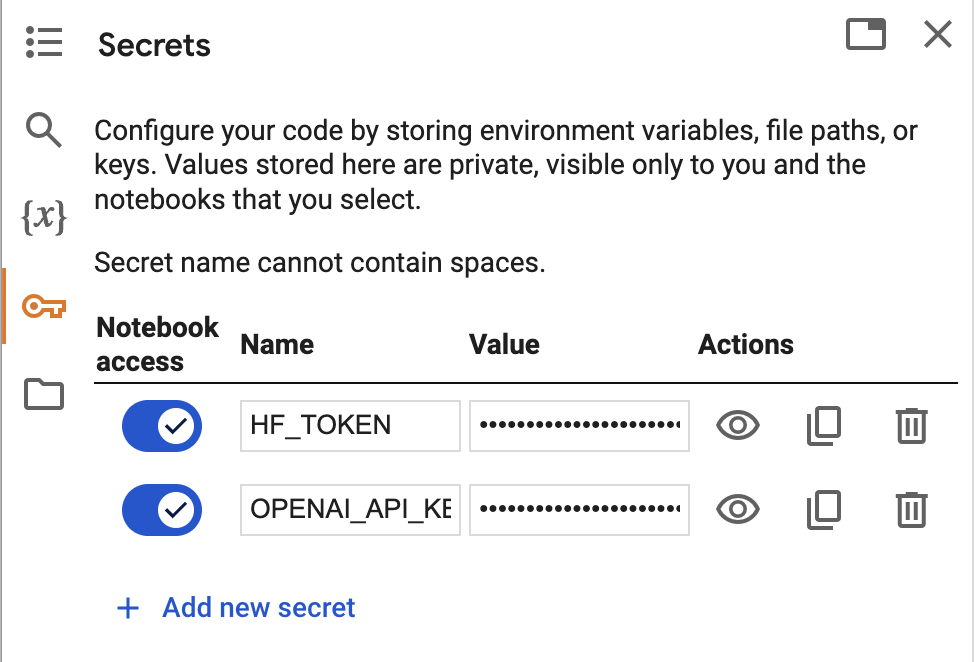

In [3]:
# imports

import os
import random
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset, Dataset, DatasetDict

#from items import Item

import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import numpy as np
import pickle

In [4]:
from typing import Optional
from transformers import AutoTokenizer
import re
from datasets import load_dataset

In [5]:
data = load_dataset("pgurazada1/amazon_india_products")["train"]

(…)ommerce__20191001_20191031__30k_data.csv:   0%|          | 0.00/28.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/30000 [00:00<?, ? examples/s]

In [6]:
# Investigate a particular datapoint
datapoint = data[2]

In [7]:
datapoint

{'Uniq Id': '41654633cce38c8650690f6dbac01fd3',
 'Crawl Timestamp': '2019-10-30 09:53:23 +0000',
 'Category': 'Skin Care',
 'Product Title': ' Generic 1 Pc brand snail eye cream remove dark circle eye lifting instant ageless snail cream for eye care anti wrinkle eyes cream 20g ',
 'Product Description': 'Use: eye, item type: cream, net wt: 20g, gzzz: ygzwbz, model number: lkwnys, gender: female, certification: gzzz, feature: moisturizing, dark circle, anti-puffiness, anti-aging, brand name: laikou, certificate number: 2014028630, ingredient: cream, country/region of manufacture: china, eye care features: eye cream, product name: snail extract cream, applicable to the crowd: general, specifications: normal specifications, origin: shantou, guangdong province, unit type: piece, package weight: ,package size:',
 'Brand': 'Generic',
 'Pack Size Or Quantity': None,
 'Mrp': '1824.00',
 'Price': '1042.00',
 'Site Name': 'Amazon In',
 'Offers': '42.87%',
 'Combo Offers': None,
 'Stock Availibil

In [8]:
# How many have prices?

prices = 0
for datapoint in data:
    try:
        price = float(datapoint["Mrp"] or 0.0)
        if price > 0.0:
            prices += 1
    except ValueError as e:
        pass

print(f"There are {prices:,} with prices which is {prices/len(data)*100:,.1f}%")

There are 29,240 with prices which is 97.5%


In [9]:
import pandas as pd
df  = pd.DataFrame(data)

# Round the Mrp column to avoid data type issues downstream



In [10]:
df.iloc[58]

,58
Uniq Id,7602f259a7d1d2c35904f1aca7f43923
Crawl Timestamp,2019-10-30 02:32:10 +0000
Category,Bath & Shower
Product Title,Donna Karan Cashmere Mist Hand Treatment Crem...
Product Description,Cashmere mist by donna Karan for women - 2.5 o...
Brand,Donna Karan
Pack Size Or Quantity,None
Mrp,7034.50
Price,7034.50
Site Name,Amazon In


In [11]:
#Drop the rows where the price is none and then delete rows where price is 0.0

df = df.dropna(subset=['Mrp'])



In [12]:
#Get the raw df to see th diferent values of the price

df.to_csv('raw_df.csv')

In [13]:
df.dtypes

,0
Uniq Id,object
Crawl Timestamp,object
Category,object
Product Title,object
Product Description,object
Brand,object
Pack Size Or Quantity,object
Mrp,object
Price,object
Site Name,object


In [14]:
df.head()

,Uniq Id,Crawl Timestamp,Category,Product Title,Product Description,Brand,Pack Size Or Quantity,Mrp,Price,Site Name,Offers,Combo Offers,Stock Availibility,Product Asin,Image Urls
0,eb49cc038190f6f03c272f79fbbce894,2019-10-30 11:38:11 +0000,Skin Care,Lee posh Lactic Acid 60% Anti ageing Pigmenta...,PROFESSIONAL GRADE Face Peel: this peel stimul...,Lee Posh,None,2000.00,799.00,Amazon In,60.05%,None,YES,B072BGHNJ1,https://images-na.ssl-images-amazon.com/images...
1,1657cc30c438affede6a5060d6847363,2019-10-31 15:46:54 +0000,Skin Care,Branded SLB Works New 1.5mm Titanium 1200 nee...,Item name: 1.5mm titanium 1200 needles microne...,SLB Works,None,2040.00,2040.00,Amazon In,0%,None,YES,B07QDTZYSJ,https://images-na.ssl-images-amazon.com/images...
2,41654633cce38c8650690f6dbac01fd3,2019-10-30 09:53:23 +0000,Skin Care,Generic 1 Pc brand snail eye cream remove dar...,"Use: eye, item type: cream, net wt: 20g, gzzz:...",Generic,None,1824.00,1042.00,Amazon In,42.87%,None,YES,B07DCSN8MP,https://images-na.ssl-images-amazon.com/images...
3,08b1bd85c3efc2d7aa556fd79b073382,2019-10-29 16:16:52 +0000,Skin Care,Generic Anti Snoring Snore Stopper Sleep Apne...,Prevent the tongue from dropping backward or b...,Generic,None,2185.00,1399.00,Amazon In,35.97%,None,YES,B07GLW9VQN,https://images-na.ssl-images-amazon.com/images...
4,3ac3f213732512d1d11bb73ab3b1900f,2019-10-31 09:32:06 +0000,Grocery & Gourmet Foods,Harveys Crunchy & Creame Gourmet Delicacies C...,Harvey's wafer Cream Wafer 110g. Made in India,Harveys,None,594.00,570.00,Amazon In,4.04%,None,YES,B07NFYYLF1,https://images-na.ssl-images-amazon.com/images...


In [15]:
# CHange the data tyoe of the column to float
df['Mrp'].fillna('0', inplace=True)
import re

def clean_price(price_str):
  str_price = str(price_str)
  """Cleans a price string by removing extra decimal points."""
  if str_price.count('.') ==2:
    cleaned_price = re.sub(r"\.", "", str_price.strip(), count=1)
    return cleaned_price
  else:
    return str_price

<ipython-input-15-25ba4a9d1f50>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Mrp'].fillna('0', inplace=True)


In [16]:
df['Cleaned_MRP']= df['Mrp'].apply(lambda x : clean_price(x))

In [17]:
# added code to colab

In [18]:
# apply the clean price function

df['Mrp'] = df['Mrp'].apply(lambda x : clean_price(x))
df['dec_count'] = df['Mrp'].apply(lambda x:[0 if x is None else x.count('.')][0])


In [19]:
df.dtypes

,0
Uniq Id,object
Crawl Timestamp,object
Category,object
Product Title,object
Product Description,object
Brand,object
Pack Size Or Quantity,object
Mrp,object
Price,object
Site Name,object


## Check before we use the Item class if the data frame consists of product description, title and Mrp

In [20]:
#df[df['Product Description'].isna()==True] #1907 rows

#df[df['Product Title'].isna()==True] #0 rows
#df[df['Mrp']==0.0] # 0 rows

In [21]:
df.shape

(29301, 17)

In [22]:
df[df['Product Description'].isna()==True]

,Uniq Id,Crawl Timestamp,Category,Product Title,Product Description,Brand,Pack Size Or Quantity,Mrp,Price,Site Name,Offers,Combo Offers,Stock Availibility,Product Asin,Image Urls,Cleaned_MRP,dec_count
41,fb5f58e96d3ad0f614c3205d484236e6,2019-10-31 08:40:01 +0000,Grocery & Gourmet Foods,Wonderland Foods Roasted & Salted Cashews 200...,None,Wonderland,200 Grams,360.00,311.00,Amazon In,13.61%,None,YES,B01M7RNC92,https://images-na.ssl-images-amazon.com/images...,360.00,1
42,5782bea6213fc3998f3be9d0574e34a6,2019-10-30 05:33:56 +0000,Skin Care,"Bekind Rose Flower Powder, 40 g (Pack of 4)",None,Bekind,None,492.00,292.00,Amazon In,40.65%,None,YES,B075R7SD9F,https://images-na.ssl-images-amazon.com/images...,492.00,1
47,33df63d0abc9cb54b4d659d5b7b02791,2019-10-30 05:55:53 +0000,Bath & Shower,FidgetGear Wooden Christmas Series Hanging Pe...,None,FidgetGear,None,645.98,514.00,Amazon In,20.43%,None,YES,B07YPLR5QP,https://images-na.ssl-images-amazon.com/images...,645.98,1
49,d097e144c3d658845ff5b4bece86530f,2019-10-30 04:12:30 +0000,Skin Care,3nh Gel SPA Socks Moisturizing Whitening Exfo...,None,3nh,None,1738.00,993.00,Amazon In,42.87%,None,YES,B07Y3LQZH8,https://images-na.ssl-images-amazon.com/images...,1738.00,1
112,d95cfa2c31127e4388bbd4c3e623137d,2019-10-30 11:38:40 +0000,Skin Care,KAZIMA ALOE VERA COLD CREAM (100g) with Almon...,None,KAZIMA,99.8 g,235.00,235.00,Amazon In,0%,None,YES,B07L1LWC76,https://images-na.ssl-images-amazon.com/images...,235.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29961,ef7752a0b25222447f13480e351b162a,2019-10-30 04:24:19 +0000,Skin Care,Madofy Grade a thanaka (tanaka) powder 50gm k...,None,MADOFY,49.9 g,1479.00,1099.00,Amazon In,25.69%,None,YES,B07PXXBQYQ,https://images-na.ssl-images-amazon.com/images...,1479.00,1
29968,c7153c3b35f6654c21a86c33a8b5cf0b,2019-10-31 04:22:08 +0000,Detergents & Dishwash,"EPIC Mountain Blue Laundry Detergent Liquid,D...",None,Epic,None,250.00,169.00,Amazon In,32.4%,None,YES,B07NHJJ2VC,https://images-na.ssl-images-amazon.com/images...,250.00,1
29994,390d24de64395cc8a66c8e5d43c03c0a,2019-10-29 03:28:49 +0000,Fragrance,Rose Water & saffron Water Combo,None,Aadi Vedaa,None,599.00,599.00,Amazon In,0%,None,YES,B076GM24HR,https://images-na.ssl-images-amazon.com/images...,599.00,1
29997,6038643bc2adfd0228acf4eeb8c4a4fc,2019-10-30 22:54:39 +0000,Skin Care,Elancyl Slim Design Flat Stomach 150ml,None,None,None,7287.00,7287.00,Amazon In,0%,None,YES,B078S7K42M,https://images-na.ssl-images-amazon.com/images...,7287.00,1


In [23]:
final_df = df[~df['Product Description'].isna()]

In [24]:
final_df.shape

(27394, 17)

In [25]:
final_df.columns

Index(['Uniq Id', 'Crawl Timestamp', 'Category', 'Product Title',
       'Product Description', 'Brand', 'Pack Size Or Quantity', 'Mrp', 'Price',
       'Site Name', 'Offers', 'Combo Offers', 'Stock Availibility',
       'Product Asin', 'Image Urls', 'Cleaned_MRP', 'dec_count'],
      dtype='object')

In [26]:

BASE_MODEL = "meta-llama/Meta-Llama-3.1-8B"

MIN_TOKENS = 150 # Any less than this, and we don't have enough useful content
MAX_TOKENS = 160 # Truncate after this many tokens. Then after adding in prompt text, we will get to around 180 tokens

MIN_CHARS = 300
CEILING_CHARS = MAX_TOKENS * 7

class Item:
    """
    An Item is a cleaned, curated datapoint of a Product with a Price
    """

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
    PREFIX = "Price is"
    QUESTION = "How much does this cost to the nearest Indian Rupee?"
    REMOVALS = ['"Batteries Included?": "No"', '"Batteries Included?": "Yes"', '"Batteries Required?": "No"', '"Batteries Required?": "Yes"', "By Manufacturer", "Item", "Date First", "Package", ":", "Number of", "Best Sellers", "Number", "Product "]

    title: str
    price: float
    category: str
    token_count: int = 0
    details: Optional[str]
    prompt: Optional[str] = None
    include = False

    def __init__(self, data):
        self.title = data['Product Title']
        self.price = data['Mrp']
        self.parse(data)

    def scrub_details(self):
        """
        Clean up the details string by removing common text that doesn't add value
        """
        details = self.details
        for remove in self.REMOVALS:
            details = details.replace(remove, "")
        return details

    def scrub(self, stuff):
        """
        Clean up the provided text by removing unnecessary characters and whitespace
        Also remove words that are 7+ chars and contain numbers, as these are likely irrelevant product numbers
        """
        stuff = re.sub(r'[\[\]"{}【】\s]+', ' ', stuff).strip()
        stuff = stuff.replace(" ,", ",").replace(",,,",",").replace(",,",",")
        words = stuff.split(' ')
        select = [word for word in words if len(word)<7 or not any(char.isdigit() for char in word)]
        return " ".join(select)

    def parse(self, data):
        """
        Parse this datapoint and if it fits within the allowed Token range,
        then set include to True
        """
        # ADD : Code block to identify and remove the rows where product description is not available
        self.contents = data['Product Description']
        if self.contents:
            self.contents += '\n'
        if len(self.contents) > MIN_CHARS:
            self.contents = self.contents[:CEILING_CHARS]
            text = f"{self.scrub(self.title)}\n{self.scrub(self.contents)}"
            tokens = self.tokenizer.encode(text, add_special_tokens=False)
            if len(tokens) > MIN_TOKENS:
                tokens = tokens[:MAX_TOKENS]
                text = self.tokenizer.decode(tokens)
                self.make_prompt(text)
                self.include = True

    def make_prompt(self, text):
        """
        Set the prompt instance variable to be a prompt appropriate for training
        """
        self.prompt = f"{self.QUESTION}\n\n{text}\n\n"
        self.prompt += f"{self.PREFIX}{str(round(self.price))}.00"
        self.token_count = len(self.tokenizer.encode(self.prompt, add_special_tokens=False))

    def test_prompt(self):
        """
        Return a prompt suitable for testing, with the actual price removed
        """
        return self.prompt.split(self.PREFIX)[0] + self.PREFIX

    def __repr__(self):
        """
        Return a String version of this Item
        """
        return f" {self.QUESTION}\n{self.title}  \n   The description of the product is:   {self.contents} \n {self.PREFIX}= ₹{self.price}"



tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

In [27]:
def parse(data):
    """
    Parse this datapoint and if it fits within the allowed Token range,
    then set include to True
    """
    contents = data['Product Description']
    return contents

In [28]:
final_df.shape

(27394, 17)

In [29]:
Item(final_df.iloc[27100])

 How much does this cost to the nearest Indian Rupee?
 Old Spice Anti-Perspirant 2.6oz Hawkridge Solid (2 Pack)   
   The description of the product is:   Old Spice Anti-Perspirant 2.6oz Hawkridge Solid (2 Pack)
 
 Price is= ₹4849.00

In [30]:
final_df.shape[0]-1

27393

In [31]:
final_df.to_csv('final_df.csv')

We need to convert the Price column to float before executing this step

In [32]:
final_df['Mrp'] = final_df['Mrp'].astype('float64')

<ipython-input-32-63702fd71816>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['Mrp'] = final_df['Mrp'].astype('float64')


In [34]:
final_df.shape[0]-1

27393

## Outlier removal





In [40]:
import scipy.stats as stats

def remove_outliers_zscore(df, column, threshold=3):
  """
  Removes outliers from a DataFrame based on Z-score.

  Args:
    df: The DataFrame to remove outliers from.
    column: The name of the column to check for outliers.
    threshold: The number of standard deviations to use as the threshold.

  Returns:
    A new DataFrame without the outliers.
  """
  z_scores = np.abs(stats.zscore(df[column]))
  filtered_df = df[z_scores < threshold]
  return filtered_df

  # Example Usage:
  # Assuming 'final_df' is your DataFrame

  # Remove outliers based on Z-score (default threshold: 3 standard deviations)
  final_df_no_outliers = remove_outliers_zscore(final_df, 'Mrp')

  return final_df_no_outliers



final_df = remove_outliers_zscore(final_df, 'Mrp', threshold=2)




In [41]:
final_df.shape

(26040, 17)

In [42]:
items =[]
counter = 0
counter
for i in range(0, final_df.shape[0]-1):
  try:
    price= float(final_df.iloc[i]["Mrp"])
    if price > 0.0:
      item = Item(final_df.iloc[i])
      counter +=1
      #print(counter)
      #items.append(item)


      """ Below two lines are useful for the token limit to be reached."""
      if item.include:
        items.append(item)

  except ValueError as e:
    print("not included")
    pass
print(counter)

26039


In [43]:
len(items)

5521

In [44]:
import pandas as pd

def add_rows_to_dataframe(items):
  """
  Adds rows to a DataFrame with 'prompt' and 'price' columns
  based on a list of items in the format "prompt ₹price".

  Args:
    items: A list of strings, where each string is in the format "prompt ₹price".

  Returns:
    A pandas DataFrame with 'prompt' and 'price' columns.
  """

  fg = pd.DataFrame(columns=['prompt', 'price'])

  for item in items:
    try:
      prompt, price_str = str(item).split('₹')
      price = float(price_str)
      fg = fg._append({'prompt': prompt, 'price': price}, ignore_index=True)
    except (ValueError, IndexError):
      print(f"Error processing item: {item}")

  return fg



final_df = add_rows_to_dataframe(items)

<ipython-input-44-cd02b0824ebc>:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fg = fg._append({'prompt': prompt, 'price': price}, ignore_index=True)


In [45]:
final_df.shape

(5521, 2)

In [46]:
final_df.to_csv('curated_dataset.csv')

In [47]:
final_df.head()

,prompt,price
0,How much does this cost to the nearest Indian...,2040.0
1,How much does this cost to the nearest Indian...,1824.0
2,How much does this cost to the nearest Indian...,5120.0
3,How much does this cost to the nearest Indian...,390.0
4,How much does this cost to the nearest Indian...,1199.0


Save a dataset as train and test in pickle format to use it later

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
# Split data into train and test sets
train, test = train_test_split(final_df, test_size=0.2, random_state=42)

# Save train DataFrame to 'train.pkl'
train.to_pickle('train.pkl')

# Save test DataFrame to 'test.pkl'
test.to_pickle('test.pkl')

In [49]:
test.iloc[8]['prompt']

" How much does this cost to the nearest Indian Rupee?\n Pro Nature Honey 250g (100% Certified Organic)   \n   The description of the product is:   Pro nature's 100 percent certified honey - the golden standard of honey. Pro nature's 100 percent certified honey come into existence in an environment so serene, soothing and full of nature's love that you will start envying the bees responsible for our honey! The bees responsible for our honey live in the majestic hills of uttarakhand, the state of the world famous valley of flours national park, and feed on the natural sweet nectar of the chemical free plant flowers. You get the best in the form of pro nature's 100 percent organic honey because the bees get the best. And, we keep our honey's taste, character and aroma as unchanged as possible, which means that ouot honey if free of toxins and other chemicals. Pro nature's 100 percent certified organic honey - the difference you can taste.\n \n Price is= "

In [50]:
def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item['prompt'].replace(" to the nearest Indian Rupee","").replace("\n\nPrice is ₹","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is ₹"}
    ]

In [51]:
messages_for(test.iloc[0])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': ' How much does this cost?\n PINK PLUMS Diamond Face pack and Skin-Whitening Massage Cream With Vitamin E 250 ml Each (PACK OF 2)   \n   The description of the product is:   PINK PLUMS Give You Face Pack And Massage Cream COMBO (Pack-2) using the products from the Pink Plums Pack & Cream will leave your skin polished, cleansed, and feeling fresh due to the unique formula that contains rich, natural active ingredients. The Face Pack & Cream exfoliates dead skin cells and goes deep into the skin to remove blackheads and whiteheads. It contains Vitamin E, It also builds the skin’s immunity against damage and pollution.Vitamin E, helps to nourish and moisturise your skin, leaving it soft and glowing. For best results, apply Face Pack on face and neck Leave on for 15-20 minutes. Rinse with water or damp washcloth. Use daily or as needed to lighten and b

In [52]:

def get_price(s):
    s = s.replace('₹','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [53]:
import openai

# Replace with your actual OpenAI API secret key
openai.api_key = OPENAI_API_KEY
def gpt_4o_mini(item):
    response = openai.chat.completions.create(
        model="gpt-4o-mini",
        messages=messages_for(item),
        seed=42,
        max_tokens=5,
    )
    reply = response.choices[0].message.content
    return get_price(reply)

In [54]:
gpt_4o_mini(test.iloc[5])

250.0

In [55]:
test.iloc[5]['prompt']

' How much does this cost to the nearest Indian Rupee?\n Rajhans Organic Reetha Herbal Soap Nuts/Raw Reetha/Aritha Dried & Natural (Ritha) (250gm)   \n   The description of the product is:   Making a shampoo with natural products has been in the history of India. However, since our hectic schedule does not provide us with enough time now, we have started to rely on shampoos that are laden with chemicals. That shampoo bottle surely saves our time, but causes great damage to our scalp and hair. So to save your hair from further damage, here is REETHA (SOAP NUTS)for you. Benefits Of Reetha: Fights dandruff and hair fall. It increases the thickness of hair. Makes them soft and shiny. Improves the texture of hair. Exfoliates the scalp. Is soothing for your head. # Reetha for making shampoo - Boil a few soap nuts along with amla (READ) and shikhakai in water for 30-40 minutes, and mash the ingredients. Let it soak overnight. Strain the mixture in the morning. Use the liquid as your shampoo. 

In [56]:
test.iloc[5]

,3425
prompt,How much does this cost to the nearest Indian...
price,399.0


The items list is a list of Item object.

In [58]:
test.shape

(1105, 2)

In [62]:
# Convert the items into a list of json objects - a "jsonl" string
# Each row represents a message in the form:
# {"messages" : [{"role": "system", "content": "You estimate prices...

def messages_for_training(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item['prompt'].replace(" to the nearest Indian Rupee","").replace("\n \n Price is= ","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": f"Price is INR {item['price']:.2f}"}
    ]


def messages_for_validation(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item['prompt'].replace(" to the nearest Indian Rupee","").replace("\n \n Price is= ","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is INR "}
    ]

#def make_jsonl(items):

def make_jsonl(items):
  result = ""
  for i in range(0, len(items)-1):
  #for item in df.iloc[9]:
      messages = messages_for_training(train.iloc[i])
      messages_str = json.dumps(messages)
      result += '{"messages": ' + messages_str +'}\n'
  return result.strip()

In [65]:
import json
def write_jsonl(items, filename):
    with open(filename, "w") as f:
        jsonl = make_jsonl(items)
        f.write(jsonl)

In [66]:

write_jsonl(train, "fine_tune_train.jsonl")

In [67]:
write_jsonl(test, "fine_tune_validation.jsonl")

In [69]:
print(make_jsonl(train[:2]))

{"messages": [{"role": "system", "content": "You estimate prices of items. Reply only with the price, no explanation"}, {"role": "user", "content": " How much does this cost?\n Meglow Intensive Whitening Face Wash For Women ( 210 g)   \n   The description of the product is:   MEGLOW Intensive Whitening FAIRNESS FACEWASH Gently Cleans & Reveals Instant Fairness \u00e2\u20ac\u00a2 Dissolves dirt and pollutants \u00e2\u20ac\u00a2 Melts excess oil without over drying \u00e2\u20ac\u00a2 Dissolves dead surface skin \u00e2\u20ac\u00a2 Dark Spots reduction \u00e2\u20ac\u00a2 Smooth & cool formula for a hydrated skin \u00e2\u20ac\u00a2 Visible radiant complexion-Instantly Meglow Fairness Facewash for Men is an effective daily revitalizing experience for a soft, clean, bright skin & a hydrated glow. This unique formula cleanses deep down into pores dissolving oil, dirt & pollutants. It takes away dead surface skin that can dry, roughen and dull your skin texture. Skin looks fresher, healthier & 

In [71]:
with open("fine_tune_train.jsonl", "rb") as f:
    train_file = openai.files.create(file=f, purpose="fine-tune")

In [72]:
with open("fine_tune_validation.jsonl", "rb") as f:
    validation_file = openai.files.create(file=f, purpose="fine-tune")

## Weights and Biases (WANDB Integration)

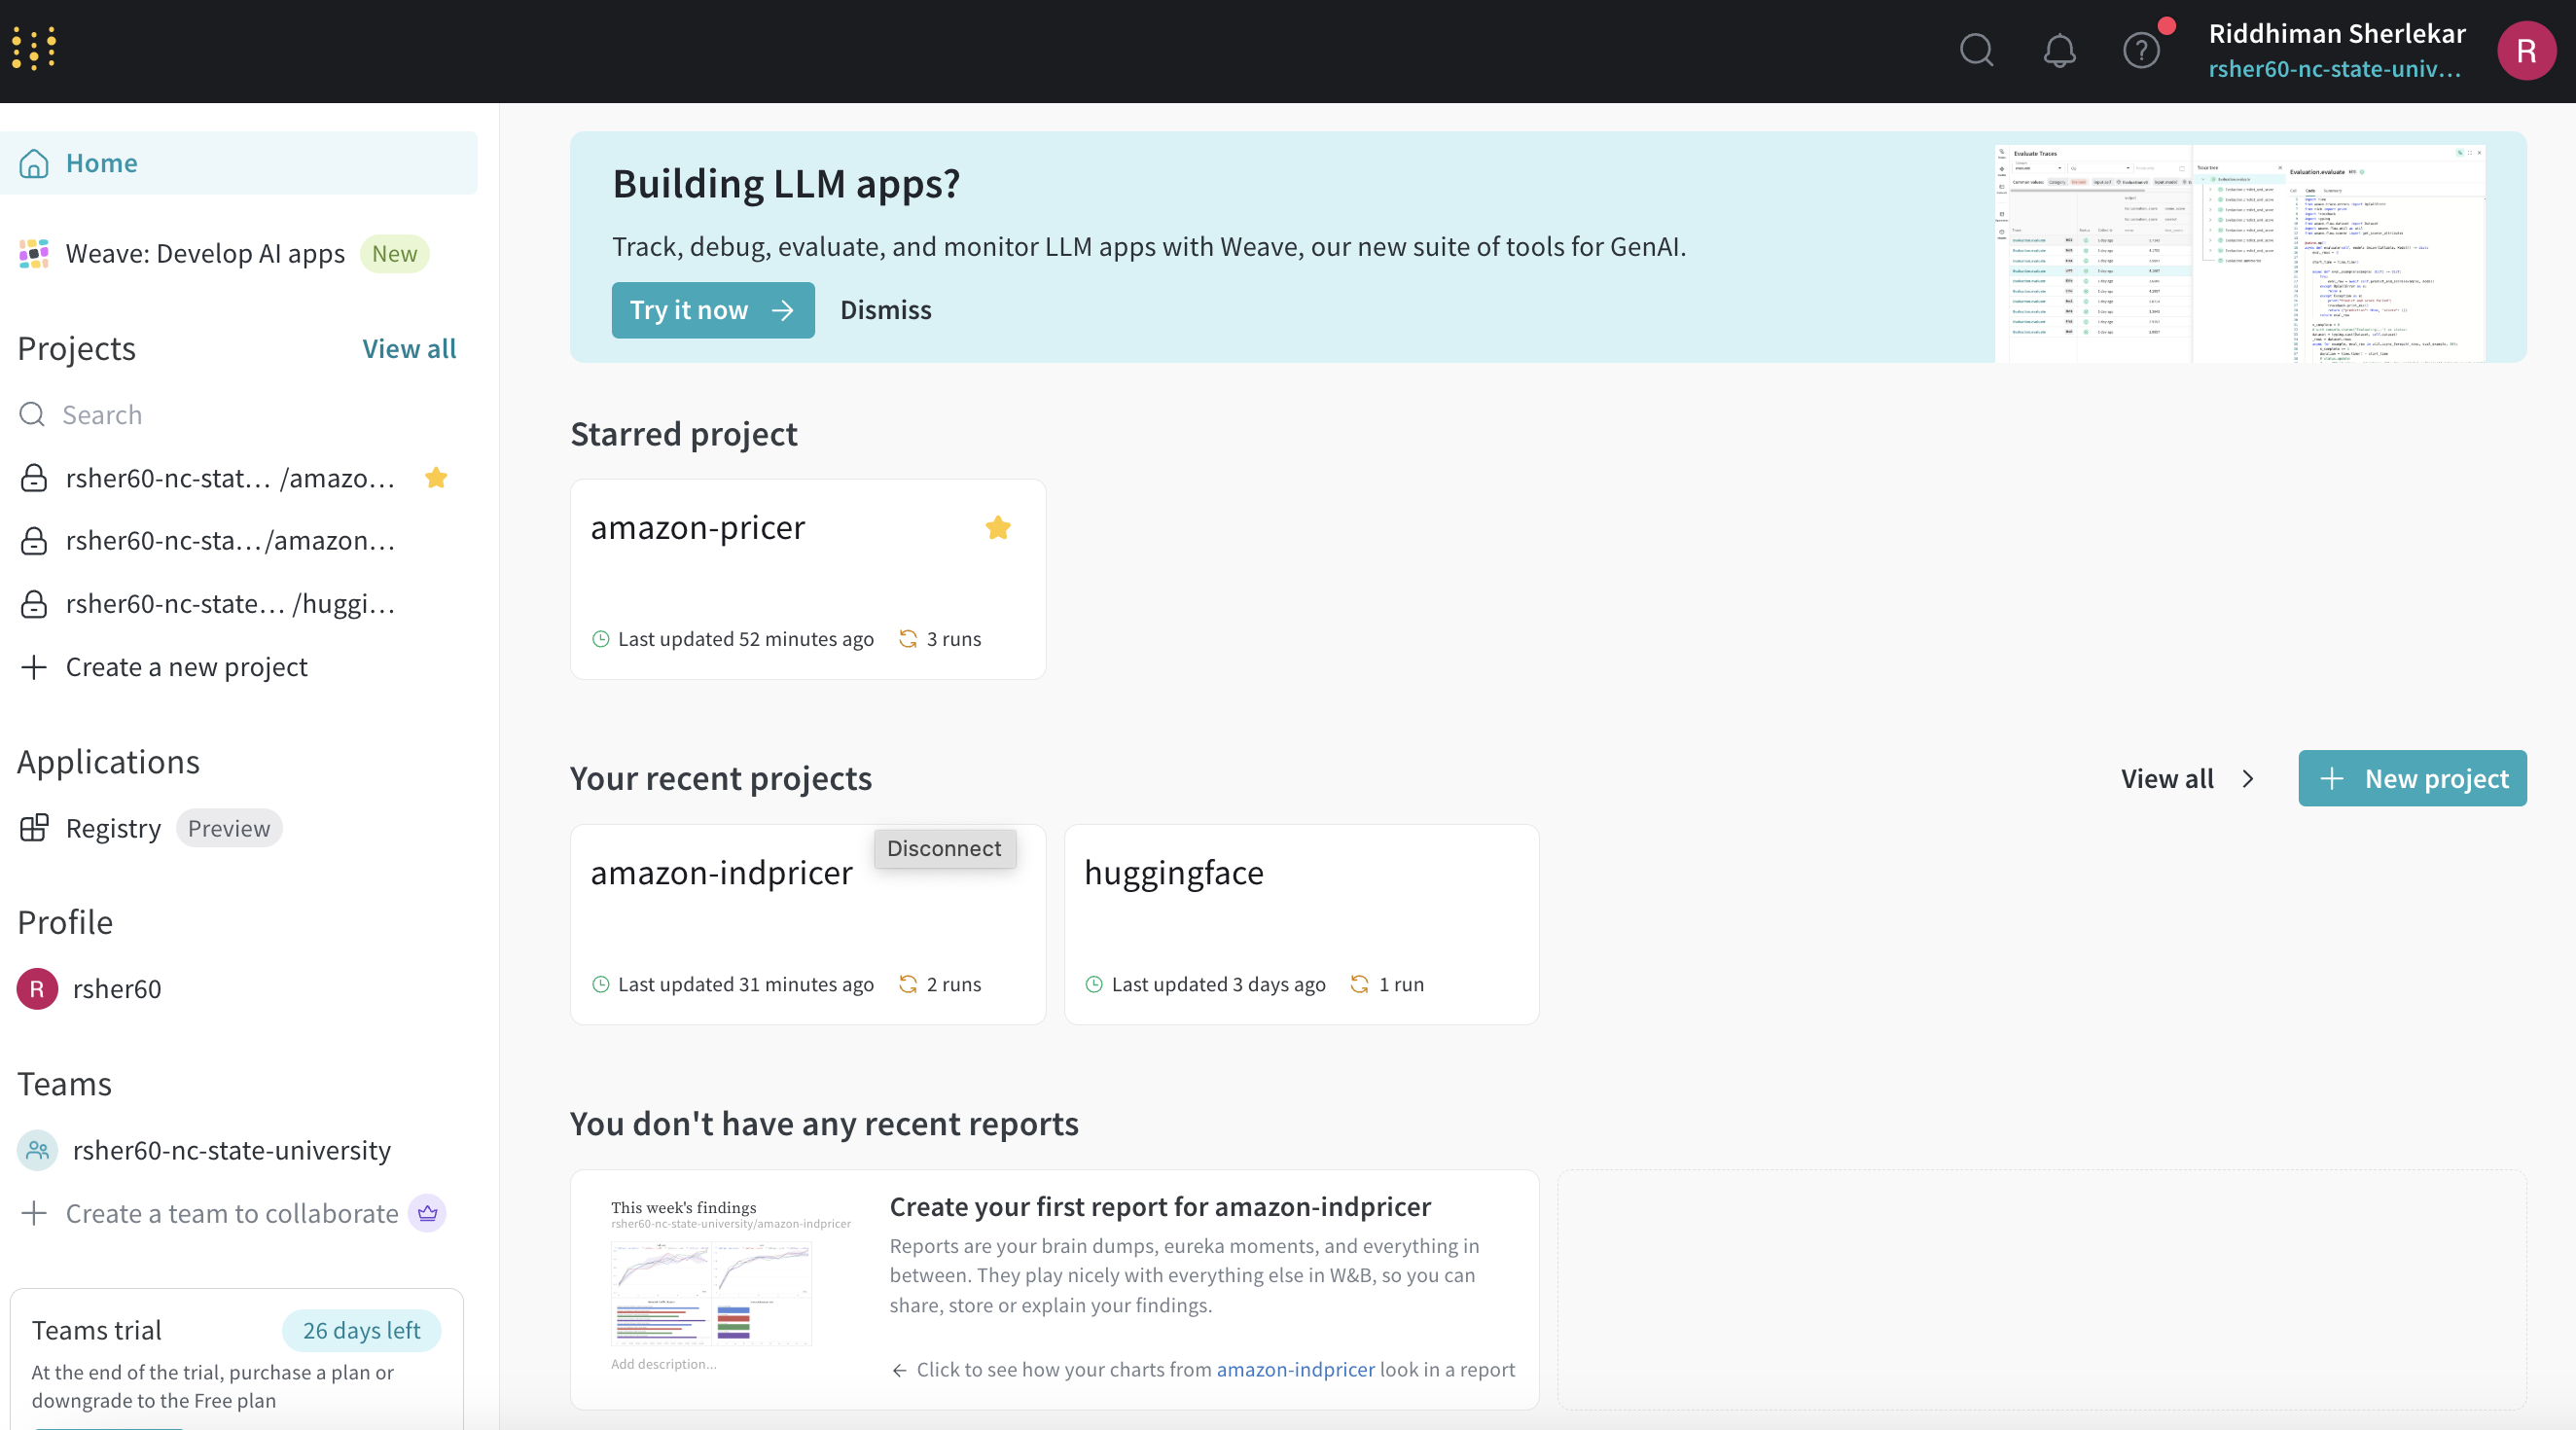

In [93]:

wandb_integration = {"type": "wandb", "wandb": {"project": "amazon-indpricer"}}

In [98]:
openai.fine_tuning.jobs.create(
    training_file=train_file.id,
    validation_file=validation_file.id,
    model="gpt-4o-mini-2024-07-18",
    seed=42,
    hyperparameters={"n_epochs": 1},
    integrations = [wandb_integration],
    suffix="indpricer"
)

FineTuningJob(id='ftjob-7qcgE7xpctFJf5lkbEwj5V0y', created_at=1735928411, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(n_epochs=1, batch_size='auto', learning_rate_multiplier='auto'), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-FfG0n9Z6nUosV4ZK8oIkuCPi', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-CMbvPkViPRNF14tECtWb4Y', validation_file='file-KdJVgE3CZ3xp66N7pKvJF2', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='amazon-indpricer', entity=None, name=None, tags=None, run_id='ftjob-7qcgE7xpctFJf5lkbEwj5V0y'))], user_provided_suffix='indpricer', method={'type': 'supervised', 'supervised': {'hyperparameters': {'batch_size': 'auto', 'learning_rate_multiplier': 'auto', 'n_epochs': 1}}})

In [102]:
openai.fine_tuning.jobs.list(limit=1)

SyncCursorPage[FineTuningJob](data=[FineTuningJob(id='ftjob-7qcgE7xpctFJf5lkbEwj5V0y', created_at=1735928411, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(n_epochs=1, batch_size=2, learning_rate_multiplier=1.8), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-FfG0n9Z6nUosV4ZK8oIkuCPi', result_files=[], seed=42, status='running', trained_tokens=None, training_file='file-CMbvPkViPRNF14tECtWb4Y', validation_file='file-KdJVgE3CZ3xp66N7pKvJF2', estimated_finish=1735930875, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='amazon-indpricer', entity=None, name=None, tags=None, run_id='ftjob-7qcgE7xpctFJf5lkbEwj5V0y'))], user_provided_suffix='indpricer', method={'type': 'supervised', 'supervised': {'hyperparameters': {'n_epochs': 1, 'batch_size': 2, 'learning_rate_multiplier': 1.8}}})], object='list', has_more=True)

In [103]:
job_id = openai.fine_tuning.jobs.list(limit=1).data[0].id

## Observing the Fine Tuned Model

In [114]:
job_id

'ftjob-7qcgE7xpctFJf5lkbEwj5V0y'

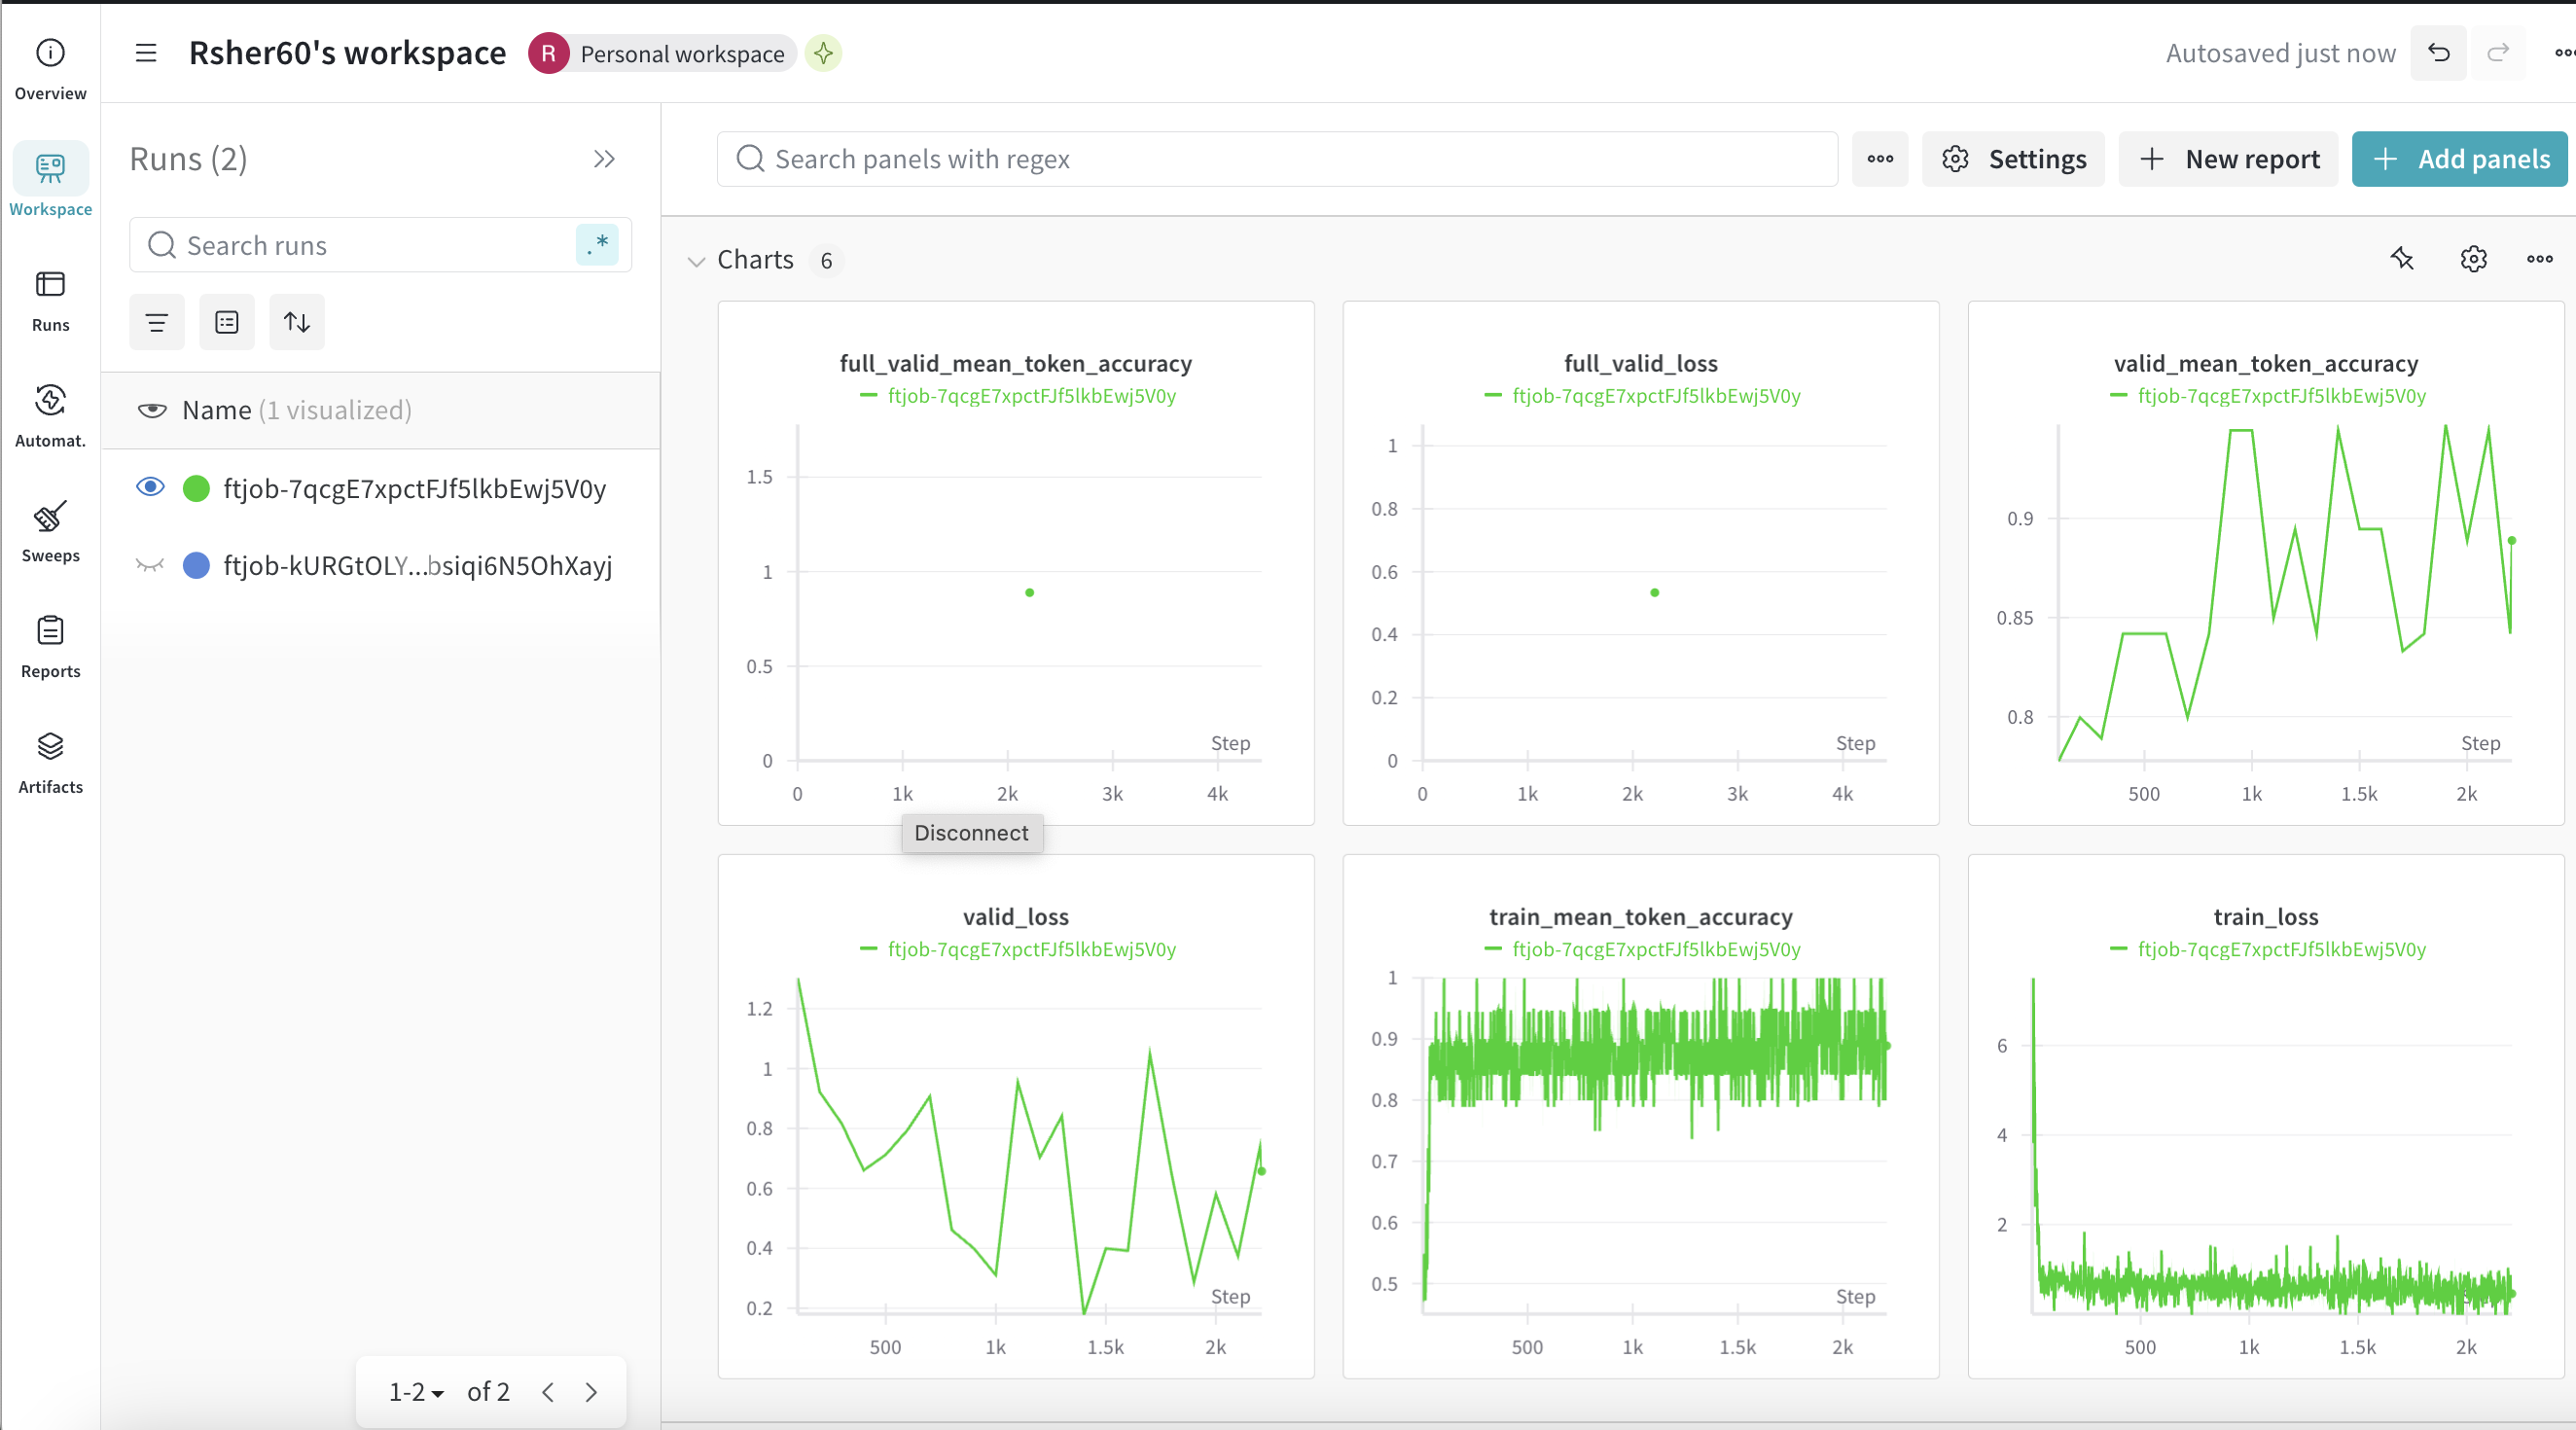

In [115]:

openai.fine_tuning.jobs.retrieve(job_id)

FineTuningJob(id='ftjob-7qcgE7xpctFJf5lkbEwj5V0y', created_at=1735928411, error=Error(code=None, message=None, param=None), fine_tuned_model='ft:gpt-4o-mini-2024-07-18:personal:indpricer:AlhEzVx4', finished_at=1735930996, hyperparameters=Hyperparameters(n_epochs=1, batch_size=2, learning_rate_multiplier=1.8), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-FfG0n9Z6nUosV4ZK8oIkuCPi', result_files=['file-AJEjbbDpLSZV46qbhy9t7q'], seed=42, status='succeeded', trained_tokens=1155881, training_file='file-CMbvPkViPRNF14tECtWb4Y', validation_file='file-KdJVgE3CZ3xp66N7pKvJF2', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='amazon-indpricer', entity=None, name=None, tags=None, run_id='ftjob-7qcgE7xpctFJf5lkbEwj5V0y'))], user_provided_suffix='indpricer', method={'type': 'supervised', 'supervised': {'hyperparameters': {'n_epochs': 1, 'batch_size': 2, 'learning_rate_multiplier': 1.8

In [116]:
fine_tuned_model_name = openai.fine_tuning.jobs.retrieve(job_id).fine_tuned_model

In [117]:
fine_tuned_model_name

'ft:gpt-4o-mini-2024-07-18:personal:indpricer:AlhEzVx4'

In [118]:

def messages_for_validation(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item['prompt'].replace(" to the nearest Indian Rupee","").replace("\n \n Price is= ","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is INR "}
    ]

In [119]:
messages_for_validation(test.iloc[3])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': ' How much does this cost?\n Happilo PP203 Premium Dry Fruits Gift Box, 400g   \n   The description of the product is:   Happilo has travelled the world to get the finest gourmet dry fruits, dried fruits, nuts, berries and dates, 100 percent natural and authentic. Indulge into the gourmet and grocery world of happilo with awesome natural nuts and dry fruits along with the unique dry fruit mixes, fusions and flavoured dry fruits, healthy seeds and dried berries specially crafted for your taste and health. Happilo dry fruit gift boxes and festive dry fruits and nuts gift pack brings health, happiness and love to gift to your colleagues, friends and family. We bring you the taste and health together in single pack in the finest of packing, packed in an art of the state facility, certified by all majors like fssai, iso etc. Every happilo pack is a perf

In [120]:
# A utility function to extract the price from a string

def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [121]:
# The function for gpt-4o-mini retrival

def gpt_fine_tuned(item):
    response = openai.chat.completions.create(
        model=fine_tuned_model_name,
        messages=messages_for_validation(item),
        seed=42,
        max_tokens=7
    )
    reply = response.choices[0].message.content
    return get_price(reply)

## Compare and draw a chart for the two outputs

In [125]:
predictions =[]

for index, row in test.iterrows():
    prediction = gpt_fine_tuned(row)
    predictions.append(prediction)
finetuned_df = pd.DataFrame({'prediction': predictions})

In [127]:
finetuned_df.shape

(1105, 1)

In [128]:
test.shape

(1105, 2)

In [129]:
finetuned_df.to_csv('finetuned.csv')

In [440]:
# concat two dataframe to compare the resutls

result_df = pd.concat([test, finetuned_df], ignore_index=True)

In [141]:
test.reset_index(inplace=True)

In [143]:
result_df = pd.concat([test, finetuned_df], ignore_index=True)

In [144]:
finetuned_df.head()

,prediction
0,999.0
1,1199.0
2,1599.0
3,599.0
4,1099.0


In [145]:
# Create DataFrames from the desired columns
df1 = pd.DataFrame({'Actual Price': test['price']})
df2 = pd.DataFrame({'Predicted Price': finetuned_df['prediction']})

# Concatenate the DataFrames along columns (axis=1)
result_df = pd.concat([df1, df2], axis=1)

In [146]:

#Code to visually compare the regression results

import matplotlib.pyplot as plt

def compare_prices(df, actual_col, predicted_col):
  """
  Compares actual and predicted prices in a DataFrame and creates a scatter plot.

  Args:
    df: The DataFrame containing the data.
    actual_col: The name of the column with actual prices.
    predicted_col: The name of the column with predicted prices.
  """

  plt.figure(figsize=(8, 6))
  plt.scatter(df[actual_col], df[predicted_col])
  plt.xlabel(f'Actual Price ({actual_col})')
  plt.ylabel(f'Predicted Price ({predicted_col})')
  plt.title('Actual vs. Predicted Prices')
  plt.plot([min(df[actual_col]), max(df[actual_col])],
           [min(df[actual_col]), max(df[actual_col])],
           color='red', linestyle='--')  # Plot the diagonal line for perfect prediction
  plt.grid(True)
  plt.show()


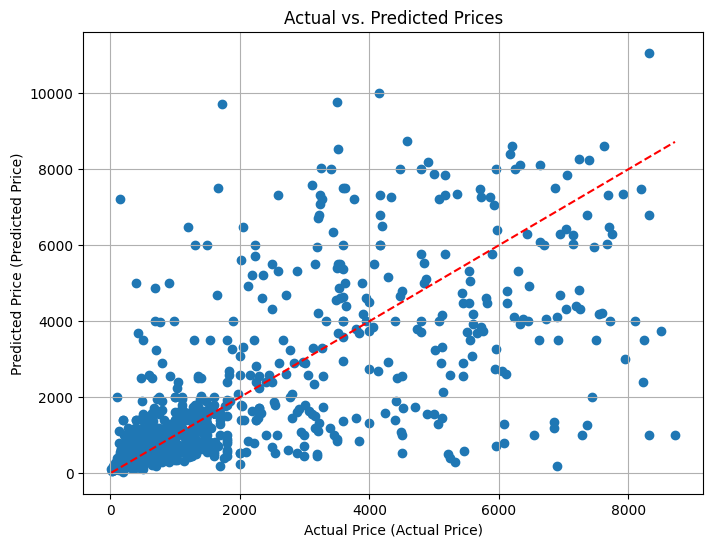

In [147]:


compare_prices(result_df, 'Actual Price', 'Predicted Price')